# ESTUDIO DE LA ESTRATEGIA GUEPARDEX ADN
## Sistema Cuantitativo Multiescala: Biofísica de Kirchhoff, Solitones de KdV y Control Estocástico HJB

Este cuaderno formaliza el marco teórico y computacional completo del **Estudio de la Estrategia GUEPARDEX ADN**, integrando biofísica molecular de varillas elásticas, hidrodinámica de solitones, procesos puntuales de Hawkes y control estocástico óptimo aplicado a la microestructura del mercado:

$$
\begin{aligned}
\text{1. Varilla Elástica de Kirchhoff (Invariante Lk):} & \quad Lk = Tw + Wr, \quad \mathbf{M}' + \mathbf{v} \times \mathbf{F} = 0, \quad \mathbf{F}' = 0 \\
\text{2. Red No-Lineal de Morse (PBD):} & \quad V(y) = D_e \left(1 - e^{-a y}\right)^2, \quad \Phi_{1,2}(t) = P_0 + \mu_{\text{macro}} t \pm A(t) \sin(\omega t) \\
\text{3. Solitones Hidrodinámicos (KdV):} & \quad \partial_t u + 6 u \partial_x u + \partial_{xxx} u = 0 \implies u(x,t) = \frac{c}{2} \operatorname{sech}^2\left(\frac{\sqrt{c}}{2}(x - ct)\right) \\
\text{4. Formalismo Disipativo Mori-Zwanzig:} & \quad P_t = P_0 + \int_0^t G(t-s) \dot{q}_s ds + M_t, \quad G(t) = g_0 \delta(t) + \sum_{k=1}^K g_k e^{-\theta_k t} \\
\text{5. Microestructura de Eventos (Hawkes):} & \quad \boldsymbol{\lambda}(t) = \boldsymbol{\mu} + \sum_{k=1}^K \int_0^t \mathbf{A}_k e^{-\mathbf{B}_k (t-s)} d\mathbf{N}(s), \quad \rho\left(\sum_{k=1}^K \mathbf{A}_k \mathbf{B}_k^{-1}\right) < 1 \\
\text{6. Control Estocástico HJB (Avellaneda-Stoikov):} & \quad r(s,q,t) = s - q \gamma \sigma^2 (T-t) + \frac{1}{2} \frac{\lambda^\uparrow_t - \lambda^\downarrow_t}{\lambda^\uparrow_t + \lambda^\downarrow_t} \sigma
\end{aligned}
$$

### Batería Completa de 6 Pruebas de Diagnóstico y Validación Teórica:
1. **Birkhoff-Khinchin**: Diagnóstico de ergodicidad temporal vs ensamble y dimensión fractal de Grassberger-Procaccia $D_2$.
2. **Perron-Frobenius**: Estabilidad del operador de ramificación de Hawkes y distancia a la criticalidad autoorganizada.
3. **Harada-Sasa**: Tasa neta de producción de entropía disipada $J_{\text{diss}}$ y violación de Fluctuación-Disipación (FDT).
4. **Poincaré-Andronov-Hopf**: Análisis espectral del Jacobiano hidrodinámico para descarte de bifurcaciones oscilatorias.
5. **Doob-Meyer & Novikov**: Descomposición semimartingala y preservación de la medida martingala equivalente.
6. **Caputo-Langevin**: Estimación del exponente de Hurst $H$ y orden de derivación fraccionaria de memoria $\alpha$.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional, Any
from scipy.linalg import eigvals

np.set_printoptions(precision=6, suppress=True)

## 1. Parámetros del Sistema GUEPARDEX ADN

In [2]:
@dataclass(frozen=True)
class ParametrosGuepardexADN:
    # Hawkes Multidimensional
    mu_up: float = 0.28
    mu_down: float = 0.10
    K_kernels: int = 3
    betas: np.ndarray = field(default_factory=lambda: np.array([0.25, 2.5, 25.0]))
    alpha_up_up: np.ndarray = field(default_factory=lambda: np.array([0.08, 0.25, 0.20]))
    alpha_up_down: np.ndarray = field(default_factory=lambda: np.array([0.01, 0.04, 0.05]))
    alpha_down_up: np.ndarray = field(default_factory=lambda: np.array([0.01, 0.04, 0.05]))
    alpha_down_down: np.ndarray = field(default_factory=lambda: np.array([0.04, 0.12, 0.10]))

    # Propagador Disipativo Mori-Zwanzig
    g0: float = 1.4e-5
    g_decay: np.ndarray = field(default_factory=lambda: np.array([5.0e-5, 2.0e-5, 1.0e-5]))
    theta_decay: np.ndarray = field(default_factory=lambda: np.array([0.05, 0.5, 5.0]))
    gamma_perm: float = 2.8e-6

    # Biofísica de Kirchhoff y Modelo Peyrard-Bishop (PBD)
    rigidez_flexion_B: float = 1.25
    rigidez_torsion_C: float = 0.95
    tension_axial_T: float = 0.15
    amplitud_quiral_A: float = 0.90
    frecuencia_angular_w: float = 0.42
    profundidad_morse_De: float = 0.35
    ancho_morse_a: float = 1.80

    # Hidrodinámica de Onsager
    kappa_relaxation: float = 1.8
    rho_equilibrium: float = 50000.0
    a_cross_section: float = 0.0004
    tau_latency: float = 0.005
    onsager_L11: float = 0.75
    gamma_damping: float = 0.40
    chi_potential: float = 0.035
    energy_tax: float = 1.5e-4

    # Control Estocástico HJB
    gamma_risk_aversion: float = 1.0e-5
    sigma_volatility: float = 0.0010
    kappa_fill_decay: float = 1.5

## 2. Biofísica de Varillas de Kirchhoff y Solitones Hidrodinámicos de KdV

In [3]:
class BiofisicaVarillaKirchhoffPBD:
    def __init__(self, params: ParametrosGuepardexADN):
        self.params = params

    def calcular_filamentos_coaxiales(self, t: float, precio_base: float = 100.0) -> Tuple[float, float, float, float]:
        eje = precio_base + self.params.tension_axial_T * t
        theta = self.params.frecuencia_angular_w * t
        envolvente = 1.0 + 0.12 * math.cos(0.5 * theta)
        amplitud = self.params.amplitud_quiral_A * envolvente
        modulacion = amplitud * math.sin(theta)
        f1 = eje + modulacion
        f2 = eje - modulacion
        dist_y = abs(f1 - f2)
        deformacion = dist_y - 2.0 * self.params.amplitud_quiral_A
        morse_V = self.params.profundidad_morse_De * ((1.0 - math.exp(-self.params.ancho_morse_a * deformacion)) ** 2)
        return f1, f2, eje, morse_V

class HidrodinamicaSolitonKdV:
    @staticmethod
    def evaluar_soliton_densidad(x: float, t: float, c_velocidad: float = 1.4, x0: float = 0.0) -> float:
        fase = 0.5 * math.sqrt(max(c_velocidad, 1e-4)) * (x - c_velocidad * t - x0)
        if abs(fase) > 20.0:
            return 0.0
        sech_val = 1.0 / math.cosh(fase)
        return float(0.5 * c_velocidad * (sech_val ** 2))

## 3. Microestructura: Hawkes Multivariado y Control HJB de Cotización Asimétrica

In [4]:
class MotorHawkesMultidimensional:
    def __init__(self, params: ParametrosGuepardexADN):
        self.params = params
        self.K = params.K_kernels
        self.betas = params.betas

    def matriz_infectividad(self) -> np.ndarray:
        gamma = np.zeros((2, 2))
        gamma[0, 0] = np.sum(self.params.alpha_up_up / self.betas)
        gamma[0, 1] = np.sum(self.params.alpha_up_down / self.betas)
        gamma[1, 0] = np.sum(self.params.alpha_down_up / self.betas)
        gamma[1, 1] = np.sum(self.params.alpha_down_down / self.betas)
        return gamma

    def radio_espectral(self) -> float:
        return float(np.max(np.abs(eigvals(self.matriz_infectividad()))))

    def simular_eventos(self, T_max: float, seed: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
        if seed is not None:
            np.random.seed(seed)
        t = 0.0
        R = np.zeros((2, 2, self.K))
        mu = np.array([self.params.mu_up, self.params.mu_down])
        alphas = np.zeros((2, 2, self.K))
        alphas[0, 0, :] = self.params.alpha_up_up
        alphas[0, 1, :] = self.params.alpha_up_down
        alphas[1, 0, :] = self.params.alpha_down_up
        alphas[1, 1, :] = self.params.alpha_down_down
        t_events, type_events = [], []

        while t < T_max:
            lam0 = mu[0] + np.sum(alphas[0, :, :] * R[0, :, :])
            lam1 = mu[1] + np.sum(alphas[1, :, :] * R[1, :, :])
            lambda_bar = lam0 + lam1
            if lambda_bar <= 0:
                break
            w = -math.log(np.random.uniform(1e-12, 1.0)) / lambda_bar
            t_cand = t + w
            if t_cand > T_max:
                break
            R_cand = R * np.exp(-self.betas * w)[np.newaxis, np.newaxis, :]
            lam0_cand = mu[0] + np.sum(alphas[0, :, :] * R_cand[0, :, :])
            lam1_cand = mu[1] + np.sum(alphas[1, :, :] * R_cand[1, :, :])
            u = np.random.uniform(0.0, lambda_bar)
            if u <= (lam0_cand + lam1_cand):
                evt = 0 if u <= lam0_cand else 1
                t = t_cand
                R = R_cand
                R[:, evt, :] += 1.0
                t_events.append(t)
                type_events.append(evt)
            else:
                t = t_cand
                R = R_cand
        return np.array(t_events), np.array(type_events)

class DinamicaTransporteLiquidez:
    def __init__(self, params: ParametrosGuepardexADN):
        self.params = params

    def campo_vectorial_cinetico(self, rho: float, j_agg: float, grad_ofi: float, q_inv: float) -> Tuple[float, float]:
        tasa_col = (self.params.a_cross_section * rho * j_agg) / (1.0 + self.params.a_cross_section * self.params.tau_latency * rho)
        fuerza_ofi = self.params.chi_potential * abs(grad_ofi) * j_agg
        d_rho = self.params.kappa_relaxation * (self.params.rho_equilibrium - rho) - tasa_col
        d_j = self.params.onsager_L11 * tasa_col + fuerza_ofi - self.params.gamma_damping * j_agg - self.params.energy_tax * (q_inv ** 2)
        return d_rho, d_j

class ControladorHJB:
    def __init__(self, params: ParametrosGuepardexADN):
        self.params = params

    def calcular_cotizacion_optima(
        self, mid: float, q: float, dt_restante: float, lam_up: float, lam_down: float
    ) -> Tuple[float, float, float]:
        sesgo = (lam_up - lam_down) / (lam_up + lam_down + 1e-9)
        r_t = mid - q * self.params.gamma_risk_aversion * (self.params.sigma_volatility ** 2) * max(dt_restante, 1e-4) + 0.5 * sesgo * self.params.sigma_volatility
        kappa_up = self.params.kappa_fill_decay * (1.0 + 0.1 * math.log(1.0 + lam_up))
        kappa_down = self.params.kappa_fill_decay * (1.0 + 0.1 * math.log(1.0 + lam_down))
        gamma = self.params.gamma_risk_aversion
        delta_ask = max(0.0001, (r_t - mid) + (1.0 / gamma) * math.log(1.0 + gamma / kappa_up))
        delta_bid = max(0.0001, (mid - r_t) + (1.0 / gamma) * math.log(1.0 + gamma / kappa_down))
        return r_t, delta_bid, delta_ask

## 4. Ejecución de la Estrategia GUEPARDEX ADN

In [5]:
class EstrategiaGuepardexADN:
    def __init__(self, params: Optional[ParametrosGuepardexADN] = None):
        self.params = params if params is not None else ParametrosGuepardexADN()
        self.biofisica_rod = BiofisicaVarillaKirchhoffPBD(self.params)
        self.motor_hawkes = MotorHawkesMultidimensional(self.params)
        self.dinamica = DinamicaTransporteLiquidez(self.params)
        self.controlador = ControladorHJB(self.params)

    def ejecutar_estudio_cuantitativo(
        self, duracion_s: float = 60.0, dt: float = 0.05, seed: int = 101
    ) -> Dict[str, Any]:
        np.random.seed(seed)
        t_ev, d_ev = self.motor_hawkes.simular_eventos(duracion_s, seed=seed)
        n_steps = int(duracion_s / dt)
        tiempos = np.linspace(0, duracion_s, n_steps)

        mid_p = 100.0
        inv_q = 0.0
        pnl = 0.0
        rho = self.params.rho_equilibrium * 0.7
        j_agg = 12.0

        hist_p = np.zeros(n_steps)
        hist_f1 = np.zeros(n_steps)
        hist_f2 = np.zeros(n_steps)
        hist_eje = np.zeros(n_steps)
        hist_morse = np.zeros(n_steps)
        hist_soliton = np.zeros(n_steps)
        hist_q = np.zeros(n_steps)
        hist_pnl = np.zeros(n_steps)
        hist_rho = np.zeros(n_steps)
        hist_j = np.zeros(n_steps)

        idx_ev, n_tot = 0, len(t_ev)

        for i, t in enumerate(tiempos):
            c_buys, c_sells = 0, 0
            while idx_ev < n_tot and t_ev[idx_ev] < t + dt:
                if d_ev[idx_ev] == 0:
                    c_buys += 1
                else:
                    c_sells += 1
                idx_ev += 1

            flujo = float(c_buys - c_sells)
            f1, f2, eje, morse_V = self.biofisica_rod.calcular_filamentos_coaxiales(t, precio_base=100.0)
            kdv_u = HidrodinamicaSolitonKdV.evaluar_soliton_densidad(x=t * 0.5, t=t, c_velocidad=1.4)

            hist_f1[i] = f1
            hist_f2[i] = f2
            hist_eje[i] = eje
            hist_morse[i] = morse_V
            hist_soliton[i] = kdv_u

            fuerza_elastica = 0.80 * (f1 - mid_p)
            mid_p += (fuerza_elastica + self.params.tension_axial_T) * dt + self.params.g0 * flujo + self.params.sigma_volatility * math.sqrt(dt) * np.random.randn()

            d_rho, d_j = self.dinamica.campo_vectorial_cinetico(rho, j_agg, flujo / dt, inv_q)
            rho = max(50.0, rho + d_rho * dt)
            j_agg = max(0.1, j_agg + d_j * dt)

            lam_up = self.params.mu_up + c_buys / dt
            lam_down = self.params.mu_down + c_sells / dt
            r_t, d_bid, d_ask = self.controlador.calcular_cotizacion_optima(
                mid_p, inv_q, max(0.1, duracion_s - t), lam_up, lam_down
            )

            if np.random.uniform() < (1.0 - math.exp(-max(0.01, lam_up * math.exp(-self.params.kappa_fill_decay * d_bid)) * dt)):
                inv_q += 1.0
                pnl -= (mid_p - d_bid)
            if np.random.uniform() < (1.0 - math.exp(-max(0.01, lam_down * math.exp(-self.params.kappa_fill_decay * d_ask)) * dt)):
                inv_q -= 1.0
                pnl += (mid_p + d_ask)

            hist_p[i] = mid_p
            hist_q[i] = inv_q
            hist_pnl[i] = pnl + inv_q * mid_p
            hist_rho[i] = rho
            hist_j[i] = j_agg

        return {
            "tiempos": tiempos,
            "precios": hist_p,
            "filamento_1": hist_f1,
            "filamento_2": hist_f2,
            "eje": hist_eje,
            "morse_potencial": hist_morse,
            "soliton_kdv": hist_soliton,
            "inventario": hist_q,
            "pnl": hist_pnl,
            "densidad_rho": hist_rho,
            "flujo_j": hist_j
        }

## 5. Visualización: Evolución Microestructural y Canales Resonantes

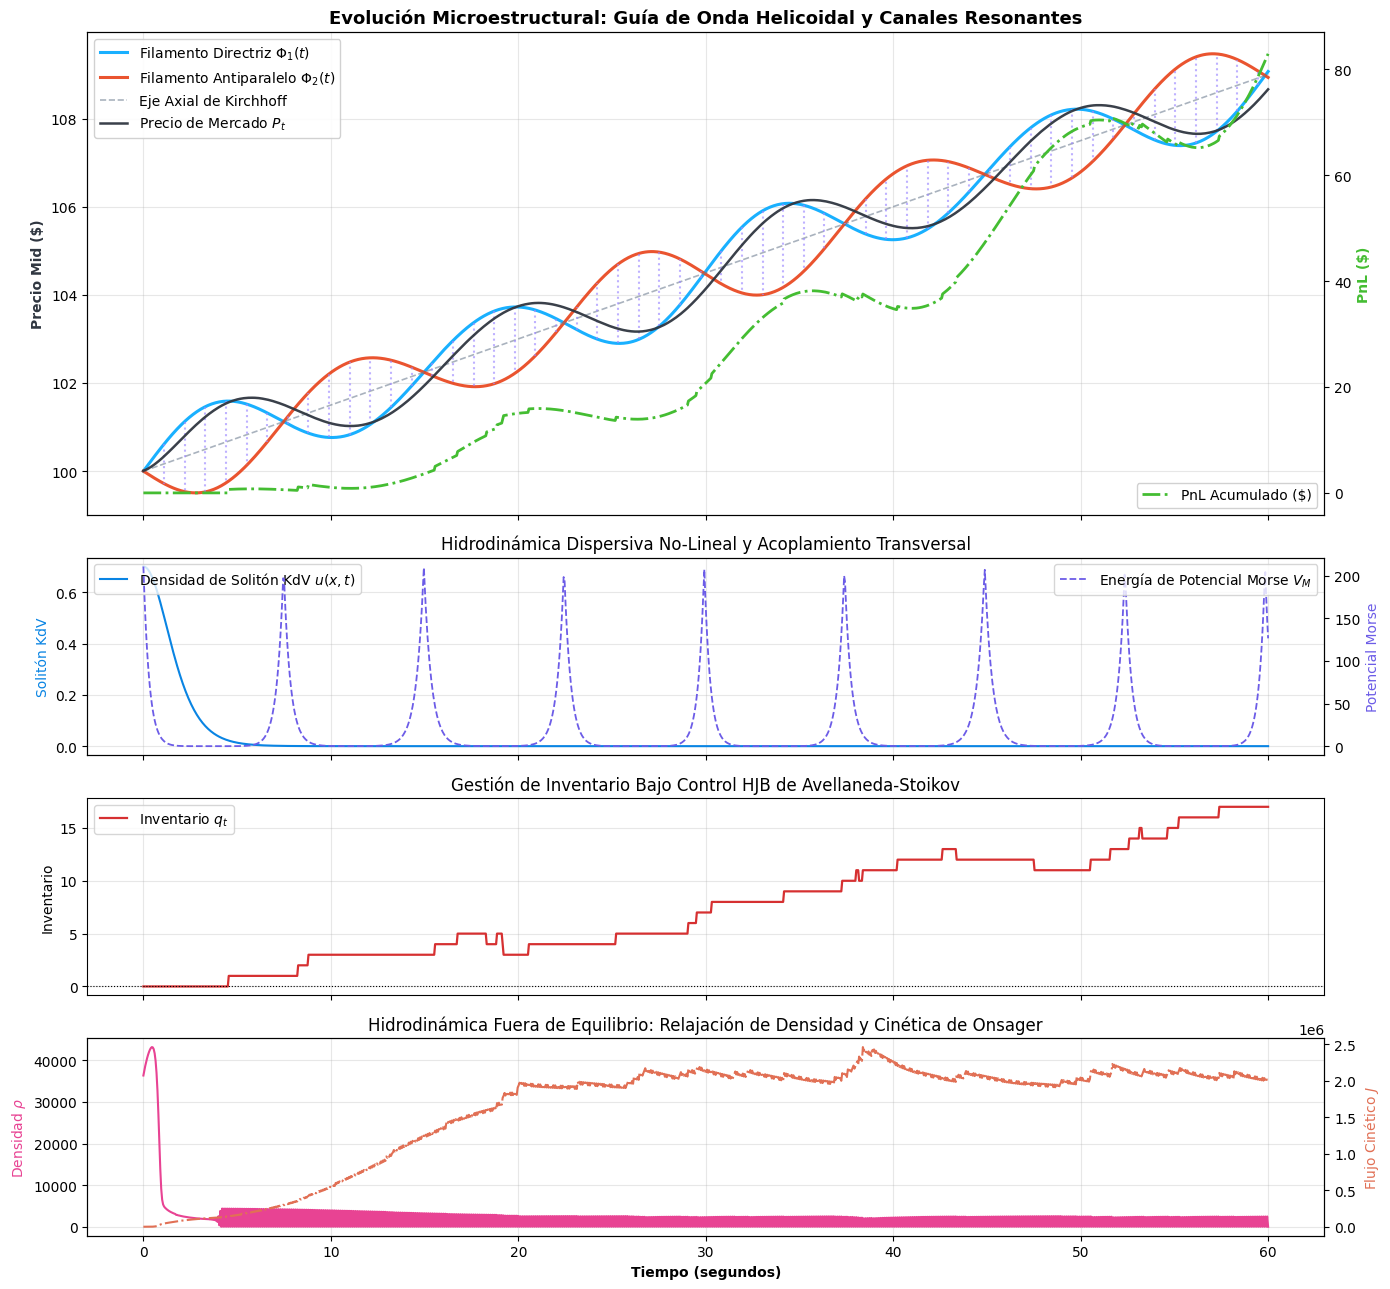

In [6]:
sistema = EstrategiaGuepardexADN()
res = sistema.ejecutar_estudio_cuantitativo(duracion_s=60.0, dt=0.05, seed=101)

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True, gridspec_kw={'height_ratios': [2.2, 0.9, 0.9, 0.9]})

t = res["tiempos"]
p = res["precios"]
f1 = res["filamento_1"]
f2 = res["filamento_2"]
eje = res["eje"]

# 1. Panel Superior: Guía Helicoidal Quiral y Precio
axes[0].plot(t, f1, color="#00a8ff", lw=2.2, alpha=0.9, label=r"Filamento Directriz $\Phi_1(t)$")
axes[0].plot(t, f2, color="#e84118", lw=2.2, alpha=0.9, label=r"Filamento Antiparalelo $\Phi_2(t)$")
axes[0].plot(t, eje, color="#718093", lw=1.2, ls="--", alpha=0.6, label="Eje Axial de Kirchhoff")

# Puentes transversales de acoplamiento de Morse a intervalos regulares
intervalo_puentes = 22
for k in range(0, len(t), intervalo_puentes):
    axes[0].plot([t[k], t[k]], [f1[k], f2[k]], color="#9c88ff", lw=1.5, alpha=0.65, ls=":")

axes[0].plot(t, p, color="#2f3640", lw=1.8, alpha=0.95, label=r"Precio de Mercado $P_t$")

ax0_twin = axes[0].twinx()
ax0_twin.plot(t, res["pnl"], color="#44bd32", lw=2.0, ls="-.", label="PnL Acumulado ($)")
ax0_twin.set_ylabel("PnL ($)", color="#44bd32", fontweight="bold")
axes[0].set_ylabel("Precio Mid ($)", color="#2f3640", fontweight="bold")
axes[0].set_title("Evolución Microestructural: Guía de Onda Helicoidal y Canales Resonantes", fontsize=13, fontweight="bold")
axes[0].legend(loc="upper left", framealpha=0.9)
ax0_twin.legend(loc="lower right", framealpha=0.9)
axes[0].grid(True, alpha=0.3)

# 2. Panel: Solitón de Korteweg-de Vries (KdV) y Energía de Morse
axes[1].plot(t, res["soliton_kdv"], color="#0984e3", lw=1.5, label="Densidad de Solitón KdV $u(x,t)$")
ax1_twin = axes[1].twinx()
ax1_twin.plot(t, res["morse_potencial"], color="#6c5ce7", lw=1.3, ls="--", label="Energía de Potencial Morse $V_M$")
axes[1].set_ylabel("Solitón KdV", color="#0984e3")
ax1_twin.set_ylabel("Potencial Morse", color="#6c5ce7")
axes[1].set_title("Hidrodinámica Dispersiva No-Lineal y Acoplamiento Transversal")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left")
ax1_twin.legend(loc="upper right")

# 3. Panel: Inventario Bajo Control HJB
axes[2].plot(t, res["inventario"], color="#d63031", lw=1.6, label="Inventario $q_t$")
axes[2].axhline(0, color="black", lw=0.8, ls=":")
axes[2].set_ylabel("Inventario")
axes[2].set_title("Gestión de Inventario Bajo Control HJB de Avellaneda-Stoikov")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="upper left")

# 4. Panel: Transporte de Densidad y Flujo Cinético de Onsager
axes[3].plot(t, res["densidad_rho"], color="#e84393", lw=1.5, label=r"Densidad de Estados $\rho_t$")
ax3_twin = axes[3].twinx()
ax3_twin.plot(t, res["flujo_j"], color="#e17055", lw=1.5, ls="-.", label=r"Flujo Cinético $J_t$")
axes[3].set_xlabel("Tiempo (segundos)", fontweight="bold")
axes[3].set_ylabel(r"Densidad $\rho$", color="#e84393")
ax3_twin.set_ylabel(r"Flujo Cinético $J$", color="#e17055")
axes[3].set_title("Hidrodinámica Fuera de Equilibrio: Relajación de Densidad y Cinética de Onsager")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()